# Aesop AbstractGraph embedding and clustering

This notebook configures and runs the experiment implemented in `experiments/aesop_graph_embeddings_clustering.py`, then displays clustering metrics and representative tales. The module handles corpus loading, graph and embedding checkpoints, vectorization, clustering, and the results manifest.

Graph extraction and text embeddings use hosted APIs and may incur charges. Install with `pip install -e '.[dev,abstractgraph]'`. Generated data is stored under `data/processed/aesop_abstractgraph/`.


In [ ]:
from pathlib import Path
import sys
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display, Markdown
from sklearn.decomposition import PCA
from sklearn.metrics import pairwise_distances

ROOT = Path.cwd()
if not (ROOT / "configs").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from experiments.aesop_graph_embeddings_clustering import run_experiment

SMOKE_TEST = True
SMOKE_LIMIT = 5
EMBED_NODES = True
EMBEDDING_MODEL = "text-embedding-3-small"
RANDOM_SEED = 17
NBITS = 14

experiment = run_experiment(
    ROOT,
    smoke_test=SMOKE_TEST,
    smoke_limit=SMOKE_LIMIT,
    embed_nodes=EMBED_NODES,
    embedding_model=EMBEDDING_MODEL,
    random_seed=RANDOM_SEED,
    nbits=NBITS,
)
stories = experiment["stories"]
metadata = experiment["metadata"]
graphs = experiment["graphs"]
graph_matrix = experiment["graph_matrix"]
text_matrix = experiment["text_matrix"]
graph_features = experiment["graph_features"]
text_features = experiment["text_features"]
cluster_results = experiment["cluster_results"]
metric_rows = experiment["metric_rows"]
agreement_rows = experiment["agreement_rows"]
max_k = experiment["max_k"]
n_tales = len(stories)
print(f"Tales: {n_tales} | graph vectors: {graph_matrix.shape} | text vectors: {text_matrix.shape}")
print(f"Results manifest: {experiment['manifest_path']}")


## Compare clusterings

Metric scores are inspection aids, not proof of semantic quality. Compare representative tales and boundary cases before drawing conclusions.


In [5]:
try:
    import pandas as pd
    metrics = pd.DataFrame(metric_rows).sort_values(
        ["representation", "silhouette"], ascending=[True, False]
    )
    display(metrics)
except ImportError:
    display(metric_rows)

for row in agreement_rows:
    print(f"k={row['k']}: ARI={row['ari']:.3f}, NMI={row['nmi']:.3f}")


,representation,algorithm,k,silhouette,calinski_harabasz,davies_bouldin
0,AbstractGraph,kmeans,2,0.294392,3.085346,0.418575
3,AbstractGraph,agglomerative,2,0.294392,3.085346,0.418575
1,AbstractGraph,kmeans,3,0.203032,3.591249,0.356720
4,AbstractGraph,agglomerative,3,0.203032,3.591249,0.356720
2,AbstractGraph,kmeans,4,0.136187,6.747775,0.260961
5,AbstractGraph,agglomerative,4,0.136187,6.747775,0.260961
6,Direct text,kmeans,2,0.040882,1.210770,1.518807
9,Direct text,agglomerative,2,0.040882,1.210770,1.518807
7,Direct text,kmeans,3,0.022094,1.153979,1.025289
10,Direct text,agglomerative,3,0.022094,1.153979,1.025289


k=2: ARI=-0.154, NMI=0.202
k=3: ARI=-0.316, NMI=0.395
k=4: ARI=-0.111, NMI=0.792


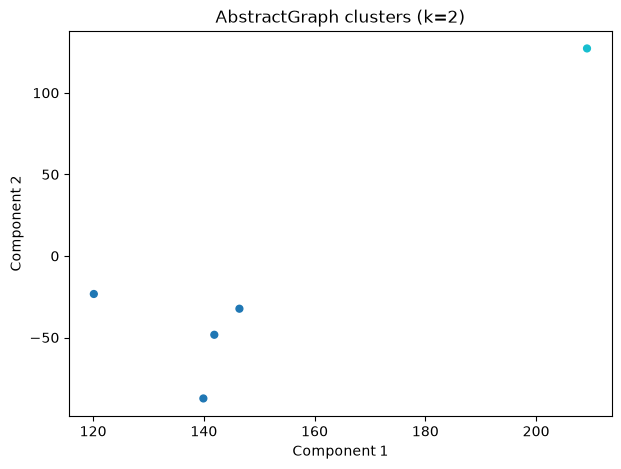

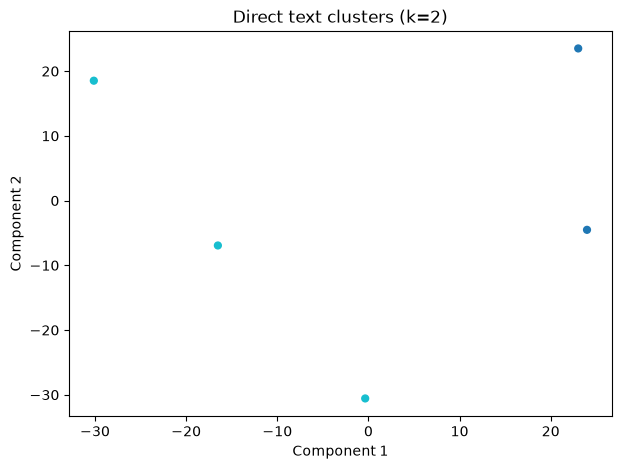

### Cluster 0 (4 tales) — representative: THE DAW IN BORROWED FEATHERS


THE DAW IN BORROWED FEATHERS (aesop-0000-71c1b92da992)
THE DAW IN BORROWED FEATHERS


[Illustration: The Daw in Borrowed Feathers]

A conceited jackdaw was vain enough to imagine that he wanted nothing
but the coloured plumes to make him as beautiful a bird as the Peacock.
Puffed up with this wise conceit, he dressed himself with a quantity
of their finest feathers, and in this borrowed garb, leaving his old
companions, tried to pass for a peacock; but he no sooner attempted
to stray with these splendid birds, than an affected strut betrayed
the sham. The offended peacocks fell upon him with their beaks, and
soon stripped him of his finery. Having turned him again into a mere
jackdaw, they drove him back to his brethren.

[Illustration]

But they, remembering what airs he had once given himself, would not
permit him to flock with them again, and treated him with well-deserved
contempt.

[Illustration]

THE SUN AND THE WIND (aesop-0001-127171afb681)
THE SUN AND THE WIND


[Illustration

### Cluster 1 (1 tales) — representative: THE FOX AND THE STORK


THE FOX AND THE STORK (aesop-0004-c6d863f7f194)
THE FOX AND THE STORK


[Illustration: The Fox and The Stork]

[Illustrations]

A fox one day invited a Stork to dinner, and being disposed to divert
himself at the expense of his guest, provided nothing for dinner
but some thin soup in a shallow dish. This the Fox lapped up very
readily, while the Stork, unable to gain a mouthful with her long
narrow bill, was as hungry at the end of dinner as when she began. The
Fox, meanwhile, said he was very sorry to see her eat so sparingly,
and hoped that the dish was seasoned to her mind. The Stork, seeing
that she was played upon, took no notice of it, but pretended to
enjoy herself extremely; and at parting begged the Fox to return the
visit. So he agreed to dine with her the next day. He arrived in good
time, and dinner was ordered forthwith; but when it was served up, he
found to his dismay, that it was nothing but minced meat in a tall,
narrow-necked jar. Down this the Stork easily thrust he

In [8]:
from textwrap import wrap

def print_wrapped_story(text, width=80):
    for paragraph in text.splitlines():
        wrapped = wrap(paragraph, width=width)
        print("\n".join(wrapped))

selected_k = min(2, n_tales - 1)
for representation, features, reducer in (
    ("AbstractGraph", graph_features, None),
    ("Direct text", text_features, PCA(n_components=2, random_state=RANDOM_SEED)),
):
    coordinates = reducer.fit_transform(features) if reducer is not None else features[:, :2]
    labels = cluster_results[(representation, "kmeans", selected_k)]
    plt.figure(figsize=(7, 5))
    plt.scatter(coordinates[:, 0], coordinates[:, 1], c=labels, cmap="tab10", s=24)
    plt.title(f"{representation} clusters (k={selected_k})")
    plt.xlabel("Component 1")
    plt.ylabel("Component 2")
    plt.show()

labels = cluster_results[("AbstractGraph", "kmeans", selected_k)]
for label in sorted(set(labels)):
    members = np.flatnonzero(labels == label)
    distances = pairwise_distances(graph_features[members], metric="euclidean")
    medoid_index = members[int(np.argmin(distances.mean(axis=1)))]
    display(Markdown(
        f"### Cluster {label} ({len(members)} tales) — "
        f"representative: {metadata[medoid_index]['title']}"
    ))
    for member_index in members:
        row = metadata[member_index]
        print(f"\n{row['title']} ({row['tale_id']})")
        print_wrapped_story(stories[member_index], width=80)
    graph = graphs[medoid_index]
    entity_types = Counter(data.get("type") for _node, data in graph.nodes(data=True))
    relation_names = Counter(
        data.get("relation") for _node, data in graph.nodes(data=True)
        if data.get("relation")
    )
    argument_roles = Counter(
        data.get("role") for _source, _target, data in graph.edges(data=True)
    )
    print("\nRepresentative graph summary:")
    print("Entity types:", entity_types.most_common(6))
    print("Relations:", relation_names.most_common(6))
    print("Argument roles:", argument_roles.most_common(6))


Inspect excerpts, recurring entity types, relations, argument roles, nearest tales, and boundary cases. The manifest records the corpus/configuration hashes and results alongside the cached graph artifacts.
